In [11]:
import nltk
from nltk.corpus import brown

In [12]:
brown.categories()

['adventure',
 'belles_lettres',
 'editorial',
 'fiction',
 'government',
 'hobbies',
 'humor',
 'learned',
 'lore',
 'mystery',
 'news',
 'religion',
 'reviews',
 'romance',
 'science_fiction']

In [13]:
from nltk.corpus import inaugural

In [14]:
inaugural.fileids()

['1789-Washington.txt',
 '1793-Washington.txt',
 '1797-Adams.txt',
 '1801-Jefferson.txt',
 '1805-Jefferson.txt',
 '1809-Madison.txt',
 '1813-Madison.txt',
 '1817-Monroe.txt',
 '1821-Monroe.txt',
 '1825-Adams.txt',
 '1829-Jackson.txt',
 '1833-Jackson.txt',
 '1837-VanBuren.txt',
 '1841-Harrison.txt',
 '1845-Polk.txt',
 '1849-Taylor.txt',
 '1853-Pierce.txt',
 '1857-Buchanan.txt',
 '1861-Lincoln.txt',
 '1865-Lincoln.txt',
 '1869-Grant.txt',
 '1873-Grant.txt',
 '1877-Hayes.txt',
 '1881-Garfield.txt',
 '1885-Cleveland.txt',
 '1889-Harrison.txt',
 '1893-Cleveland.txt',
 '1897-McKinley.txt',
 '1901-McKinley.txt',
 '1905-Roosevelt.txt',
 '1909-Taft.txt',
 '1913-Wilson.txt',
 '1917-Wilson.txt',
 '1921-Harding.txt',
 '1925-Coolidge.txt',
 '1929-Hoover.txt',
 '1933-Roosevelt.txt',
 '1937-Roosevelt.txt',
 '1941-Roosevelt.txt',
 '1945-Roosevelt.txt',
 '1949-Truman.txt',
 '1953-Eisenhower.txt',
 '1957-Eisenhower.txt',
 '1961-Kennedy.txt',
 '1965-Johnson.txt',
 '1969-Nixon.txt',
 '1973-Nixon.txt',
 '1

In [15]:
inaugural.words(fileids='2021-Biden.txt')[:20]

['Chief',
 'Justice',
 'Roberts',
 ',',
 'Vice',
 'President',
 'Harris',
 ',',
 'Speaker',
 'Pelosi',
 ',',
 'Leader',
 'Schumer',
 ',',
 'Leader',
 'McConnell',
 ',',
 'Vice',
 'President',
 'Pence']

In [16]:
!pip install wordcloud matplotlib

from wordcloud import WordCloud
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable


In [17]:
text1='It was at my hometown public library and  half a dozen people came out. I just kind of stood there and rambled. There were a lot of awkward silences. One guy clapped. Since then I’ve given over 500 keynote speeches. I am still getting better. I have a long way to go. One thing I’ve always done is collect speech transcripts and bits of poetry. I study them—inhale them—to see greatness in action. How do they build connection? How do they structure their messages? What’s the science? What’s the art? '
fd=nltk.FreqDist(text1.split())
fd


FreqDist({'I': 4, 'and': 3, 'a': 3, 'of': 3, 'One': 2, 'I’ve': 2, 'How': 2, 'do': 2, 'they': 2, 'What’s': 2, ...})

In [18]:
from nltk.probability import ConditionalFreqDist
cfd=ConditionalFreqDist((len(word),word) for word in text1.split())
cfd[6]

FreqDist({'What’s': 2, 'public': 1, 'people': 1, 'always': 1, 'speech': 1})

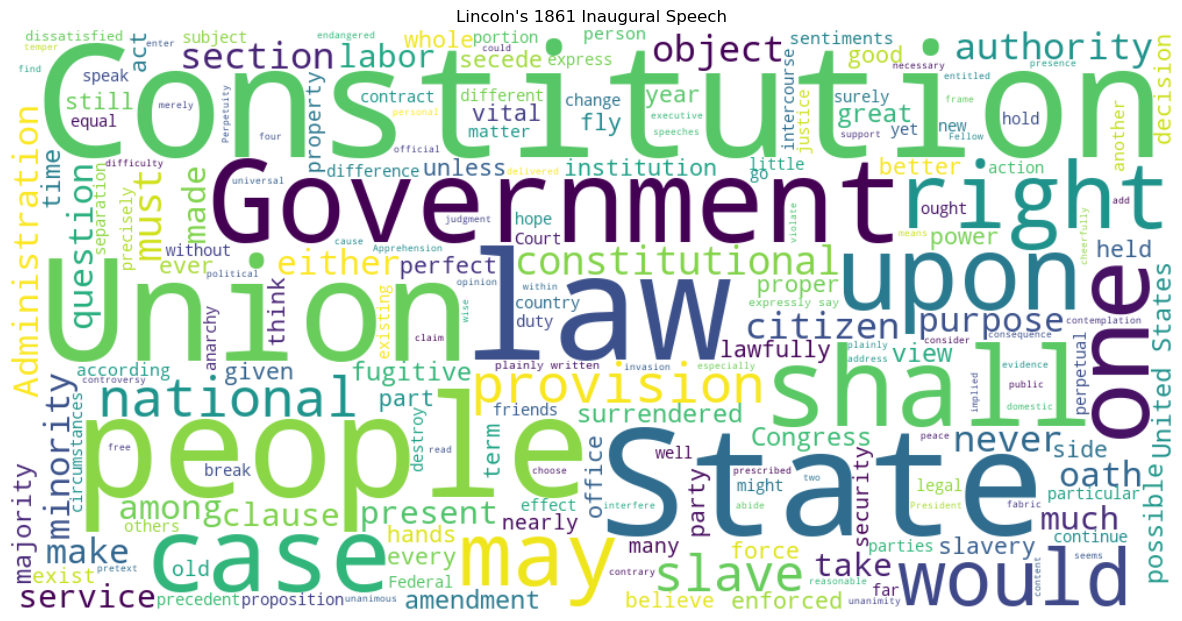

In [19]:
from nltk.corpus import inaugural, stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = inaugural.raw('1861-Lincoln.txt')

stop_words = set(stopwords.words('english'))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stop_words
).generate(text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Lincoln's 1861 Inaugural Speech")
plt.show()

In [20]:
from nltk.corpus import inaugural, stopwords
from nltk import FreqDist, ConditionalFreqDist
import string

In [21]:
#High-frequency words of Washington
stop_words = set(stopwords.words('english'))

words = inaugural.words('1789-Washington.txt')

words = [
    word.lower()
    for word in words
    if word.isalpha() and word.lower() not in stop_words
]

fd = FreqDist(words)

print(fd.most_common(20))


[('every', 9), ('government', 8), ('public', 6), ('may', 6), ('citizens', 5), ('present', 5), ('country', 5), ('one', 4), ('ought', 4), ('duty', 4), ('people', 4), ('united', 4), ('since', 4), ('fellow', 3), ('could', 3), ('hand', 3), ('nature', 3), ('happiness', 3), ('great', 3), ('good', 3)]


<Axes: title={'center': "Top 20 Words in Washington's Speech"}, xlabel='Samples', ylabel='Counts'>

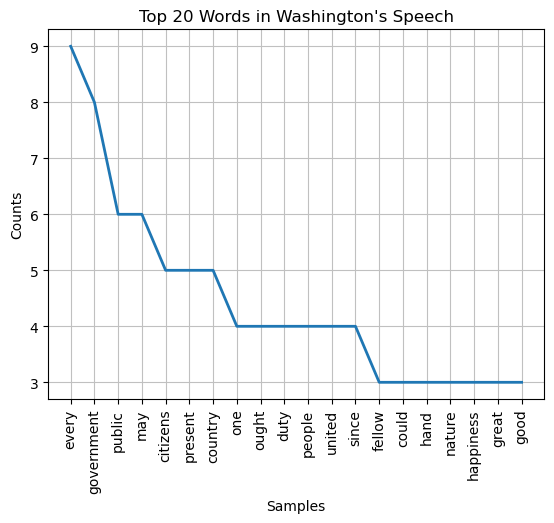

In [22]:
fd.plot(20, title="Top 20 Words in Washington's Speech")

In [23]:
#Find the president who used the longest word
longest_word = ""
president = ""

for file in inaugural.fileids():
    words = inaugural.words(file)

    for word in words:
        if word.isalpha() and len(word) > len(longest_word):
            longest_word = word
            president = file

print("President:", president)
print("Longest word:", longest_word)
print("Length:", len(longest_word))

President: 1805-Jefferson.txt
Longest word: antiphilosophists
Length: 17


In [24]:
#Use CFD (Conditional Frequency Distribution) to find high-frequency words of presidents
stop_words = set(stopwords.words('english'))

cfd = ConditionalFreqDist()

for file in inaugural.fileids():
    president = file.split("-")[1].replace(".txt", "")

    for word in inaugural.words(file):
        word = word.lower()

        if word.isalpha() and word not in stop_words:
            cfd[president][word] += 1

In [25]:
print(cfd["Washington"].most_common(10))
print(cfd["Lincoln"].most_common(10)) 


[('every', 9), ('government', 9), ('may', 7), ('citizens', 6), ('present', 6), ('country', 6), ('public', 6), ('shall', 6), ('people', 5), ('united', 5)]
[('constitution', 24), ('union', 24), ('shall', 22), ('people', 20), ('states', 19), ('government', 19), ('one', 17), ('upon', 16), ('may', 16), ('right', 14)]


In [26]:
for president in ["Washington", "Lincoln", "Obama", "Trump"]:
    print("\n", president)
    print(cfd[president].most_common(10))


 Washington
[('every', 9), ('government', 9), ('may', 7), ('citizens', 6), ('present', 6), ('country', 6), ('public', 6), ('shall', 6), ('people', 5), ('united', 5)]

 Lincoln
[('constitution', 24), ('union', 24), ('shall', 22), ('people', 20), ('states', 19), ('government', 19), ('one', 17), ('upon', 16), ('may', 16), ('right', 14)]

 Obama
[('us', 44), ('must', 25), ('nation', 18), ('america', 18), ('people', 18), ('new', 17), ('every', 15), ('time', 15), ('today', 12), ('cannot', 12)]

 Trump
[('america', 38), ('thank', 26), ('nation', 26), ('american', 24), ('country', 23), ('people', 18), ('world', 16), ('great', 16), ('every', 16), ('back', 16)]
